Import Libraries such as Pandas, Datasets, Matplotlib.pyplot and Seaborn.

In [1]:
# Importing Libraries
import ast # For string conversion into list object, and string conversion into dictionary object.
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick # To add percentage sign to y axis ticks

plt.close('all') # close all open plots

import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
# make datetime string into datetime object
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# in column job_skills, make list from string into panda series (list) object using ast.literal_eval
df["job_skills"] = df["job_skills"].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else None)

In [2]:
# In plots, FuncFormatter is to format x axis ticks as £K
from matplotlib.ticker import FuncFormatter
def pounds_k(x, pos):
    return f"£{x/1000:.0f}K"

# In scatterplots, adjustText prevents overlap of point labels
from adjustText import adjust_text

# What are the most optimum types of skills to learn for a data professional?

I filter the dataframe to show job postings from the United Kingdom whilst ensuring to create a copy of it also for data integrity. I also drop rows containing NA values in the column salary_year_avg as they are not relevant for my analysis.

In [3]:
df_UK = df[df["job_country"] == "United Kingdom"].copy()

df_UK = df_UK.dropna(subset="salary_year_avg")

df_UK

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,"[python, numpy, pandas, scikit-learn]","{'libraries': ['numpy', 'pandas', 'scikit-lear..."
2602,Data Analyst,Admin & Data Analyst,United Kingdom,via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-10 13:55:49,False,False,United Kingdom,year,51014.0,NaN,Catch22,"[excel, word, outlook]","{'analyst_tools': ['excel', 'word', 'outlook']}"
9778,Senior Data Analyst,Workday HCM Senior Data Analyst (18 month FTC),"London, UK",via Ai-Jobs.net,Contractor,False,United Kingdom,2023-07-10 13:36:15,True,False,United Kingdom,year,111175.0,NaN,WPP,"[vba, python, r, oracle, sap, excel]","{'analyst_tools': ['sap', 'excel'], 'cloud': [..."
9903,Senior Data Engineer,Senior Satellite Analytics Data Engineer,"Edinburgh, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-08-10 13:34:53,False,False,United Kingdom,year,147500.0,NaN,Verisk,"[python, sql, nosql, mongodb, mongodb, elastic...","{'cloud': ['aws'], 'databases': ['mongodb', 'e..."
13764,Data Scientist,Programmatic Data Specialist,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-11 13:22:50,False,False,United Kingdom,year,109500.0,NaN,Publicis Groupe,"[excel, powerpoint, flow]","{'analyst_tools': ['excel', 'powerpoint'], 'ot..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781461,Data Scientist,Data Scientist,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-04-04 06:31:10,False,False,United Kingdom,year,88128.0,NaN,Kuda Technologies Ltd,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
783284,Senior Data Scientist,Senior Data Scientist,"Belfast, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-28 06:14:36,False,False,United Kingdom,year,157500.0,NaN,Axiom,"[sql, r, python, aws, redshift, spark, gitlab,...","{'async': ['jira', 'confluence'], 'cloud': ['a..."
783436,Data Scientist,Insight Analyst,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-11 06:36:08,True,False,United Kingdom,year,72900.0,NaN,Xiatech,"[html, python, css, javascript, sql, bigquery,...","{'analyst_tools': ['tableau'], 'async': ['jira..."
783598,Data Engineer,Data Engineer,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-05-02 06:18:42,False,False,United Kingdom,year,96773.0,NaN,Prevail,"[python, java, scala, c#, r, redshift, aws]","{'cloud': ['redshift', 'aws'], 'programming': ..."


I create a copy of the dataframe for data integrity purposes.

In [4]:
df_UK_copy = df_UK.copy()

PROBLEM: I was attempting to convert the data in column job_type_skills into python dictionaries. However, the ast.literal_eval function crashed repeatedly. On investigation, I realised this was because there were NA values in some cells and some values were not strings. This is caused by unclean data.
ACTION: So, I had to make a wrapper function called safe_parse_dict which catches if there is a NA value in the cell and if the value is a string.
RESULT: This safely turned the values of column job_type_skills into dictionaries which could be further analysed as we will see below:

In [5]:
# This essential wrapper function checks if there are strings in column job_type_skills and catches if there are na values
# Essential when running ast.literal_eval on column as it contains na values
def safe_parse_dict(val):
    # Only parse if the value is a non-null string
    if pd.notna(val) and isinstance(val, str):
        return ast.literal_eval(val)
    # Return an empty dictionary (or None) if the data is missing
    return {} 
 # Apply safe_parse_dict function to values in column job_type_skills
df_UK_copy["job_type_skills"] = df_UK_copy["job_type_skills"].apply(safe_parse_dict)

In [6]:
df_UK_copy[["job_title_short", "job_type_skills"]]

,job_title_short,job_type_skills
1107,Data Scientist,"{'libraries': ['numpy', 'pandas', 'scikit-lear..."
2602,Data Analyst,"{'analyst_tools': ['excel', 'word', 'outlook']}"
9778,Senior Data Analyst,"{'analyst_tools': ['sap', 'excel'], 'cloud': [..."
9903,Senior Data Engineer,"{'cloud': ['aws'], 'databases': ['mongodb', 'e..."
13764,Data Scientist,"{'analyst_tools': ['excel', 'powerpoint'], 'ot..."
...,...,...
781461,Data Scientist,"{'cloud': ['gcp'], 'programming': ['python', '..."
783284,Senior Data Scientist,"{'async': ['jira', 'confluence'], 'cloud': ['a..."
783436,Data Scientist,"{'analyst_tools': ['tableau'], 'async': ['jira..."
783598,Data Engineer,"{'cloud': ['redshift', 'aws'], 'programming': ..."


Explode the dataframe by column job_type_skills. However, I came across a problem. Column job_type_skills contains a dictionary where its keys are the type of skill (as a string data type format) and its values are a list of the skills (as a list data type format). The challenge was to explode the column based on the keys of the dictionaries contained in this column. Dictionaries are not 'explodable' by nature. So, I had to take a 6-step approach in solving the problem.
1. Convert the dictionary into a list of tuples. Each tuple contains a key, value pair.
2. Explode each list into individual rows (one row per tuple per job)
3. Drop rows where there were no blank values (empty tuples resulting in NaN/None). This was 17 rows.
4. Unpack the tuples into two new columns: 'skill_type' and 'job_skills'
5. Explode the column job_skills containing the list of skills so each specific skill gets its own row
6. Drop the temporary tuple column as it is no longer required

The result of all 6 steps is a dataframe (df_UK_exploded) containing the jobs where the skills within that job are classified into skill type categories.
N.B To better see the result of each step within this 6 step process, I have included the csv files showing the changes after each step.

In [ ]:
# 1. Convert the dictionary into a list of (key, value) pairs and store the output in a new column called skills_tuples
# This is because the dictionary cannot be exploded directly
df_UK_copy["skills_tuples"] = df_UK_copy["job_type_skills"].apply(lambda d: list(d.items()))

df_UK_copy

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,skills_tuples
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,"[python, numpy, pandas, scikit-learn]","{'libraries': ['numpy', 'pandas', 'scikit-lear...","[(libraries, [numpy, pandas, scikit-learn]), (..."
2602,Data Analyst,Admin & Data Analyst,United Kingdom,via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-10 13:55:49,False,False,United Kingdom,year,51014.0,NaN,Catch22,"[excel, word, outlook]","{'analyst_tools': ['excel', 'word', 'outlook']}","[(analyst_tools, [excel, word, outlook])]"
9778,Senior Data Analyst,Workday HCM Senior Data Analyst (18 month FTC),"London, UK",via Ai-Jobs.net,Contractor,False,United Kingdom,2023-07-10 13:36:15,True,False,United Kingdom,year,111175.0,NaN,WPP,"[vba, python, r, oracle, sap, excel]","{'analyst_tools': ['sap', 'excel'], 'cloud': [...","[(analyst_tools, [sap, excel]), (cloud, [oracl..."
9903,Senior Data Engineer,Senior Satellite Analytics Data Engineer,"Edinburgh, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-08-10 13:34:53,False,False,United Kingdom,year,147500.0,NaN,Verisk,"[python, sql, nosql, mongodb, mongodb, elastic...","{'cloud': ['aws'], 'databases': ['mongodb', 'e...","[(cloud, [aws]), (databases, [mongodb, elastic..."
13764,Data Scientist,Programmatic Data Specialist,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-11 13:22:50,False,False,United Kingdom,year,109500.0,NaN,Publicis Groupe,"[excel, powerpoint, flow]","{'analyst_tools': ['excel', 'powerpoint'], 'ot...","[(analyst_tools, [excel, powerpoint]), (other,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781461,Data Scientist,Data Scientist,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-04-04 06:31:10,False,False,United Kingdom,year,88128.0,NaN,Kuda Technologies Ltd,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '...","[(cloud, [gcp]), (programming, [python, sql])]"
783284,Senior Data Scientist,Senior Data Scientist,"Belfast, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-28 06:14:36,False,False,United Kingdom,year,157500.0,NaN,Axiom,"[sql, r, python, aws, redshift, spark, gitlab,...","{'async': ['jira', 'confluence'], 'cloud': ['a...","[(async, [jira, confluence]), (cloud, [aws, re..."
783436,Data Scientist,Insight Analyst,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-11 06:36:08,True,False,United Kingdom,year,72900.0,NaN,Xiatech,"[html, python, css, javascript, sql, bigquery,...","{'analyst_tools': ['tableau'], 'async': ['jira...","[(analyst_tools, [tableau]), (async, [jira]), ..."
783598,Data Engineer,Data Engineer,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-05-02 06:18:42,False,False,United Kingdom,year,96773.0,NaN,Prevail,"[python, java, scala, c#, r, redshift, aws]","{'cloud': ['redshift', 'aws'], 'programming': ...","[(cloud, [redshift, aws]), (programming, [pyth..."


In [30]:
# 2. Explode the list into individual rows (one row per category)
df_UK_exploded = df_UK_copy.explode("skills_tuples")

df_UK_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,skills_tuples
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,"[python, numpy, pandas, scikit-learn]","{'libraries': ['numpy', 'pandas', 'scikit-lear...","(libraries, [numpy, pandas, scikit-learn])"
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,"[python, numpy, pandas, scikit-learn]","{'libraries': ['numpy', 'pandas', 'scikit-lear...","(programming, [python])"
2602,Data Analyst,Admin & Data Analyst,United Kingdom,via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-10 13:55:49,False,False,United Kingdom,year,51014.0,NaN,Catch22,"[excel, word, outlook]","{'analyst_tools': ['excel', 'word', 'outlook']}","(analyst_tools, [excel, word, outlook])"
9778,Senior Data Analyst,Workday HCM Senior Data Analyst (18 month FTC),"London, UK",via Ai-Jobs.net,Contractor,False,United Kingdom,2023-07-10 13:36:15,True,False,United Kingdom,year,111175.0,NaN,WPP,"[vba, python, r, oracle, sap, excel]","{'analyst_tools': ['sap', 'excel'], 'cloud': [...","(analyst_tools, [sap, excel])"
9778,Senior Data Analyst,Workday HCM Senior Data Analyst (18 month FTC),"London, UK",via Ai-Jobs.net,Contractor,False,United Kingdom,2023-07-10 13:36:15,True,False,United Kingdom,year,111175.0,NaN,WPP,"[vba, python, r, oracle, sap, excel]","{'analyst_tools': ['sap', 'excel'], 'cloud': [...","(cloud, [oracle])"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783598,Data Engineer,Data Engineer,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-05-02 06:18:42,False,False,United Kingdom,year,96773.0,NaN,Prevail,"[python, java, scala, c#, r, redshift, aws]","{'cloud': ['redshift', 'aws'], 'programming': ...","(programming, [python, java, scala, c#, r])"
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,"[python, sql, javascript, aws, pandas, flow, g...","{'cloud': ['aws'], 'libraries': ['pandas'], 'o...","(cloud, [aws])"
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,"[python, sql, javascript, aws, pandas, flow, g...","{'cloud': ['aws'], 'libraries': ['pandas'], 'o...","(libraries, [pandas])"
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,"[python, sql, javascript, aws, pandas, flow, g...","{'cloud': ['aws'], 'libraries': ['pandas'], 'o...","(other, [flow, git, docker])"


In [32]:
# 3. Drop rows where there were no skills (empty dictionaries resulting in NaN/None)
df_UK_exploded = df_UK_exploded.dropna(subset=["skills_tuples"])

df_UK_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,skills_tuples
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,"[python, numpy, pandas, scikit-learn]","{'libraries': ['numpy', 'pandas', 'scikit-lear...","(libraries, [numpy, pandas, scikit-learn])"
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,"[python, numpy, pandas, scikit-learn]","{'libraries': ['numpy', 'pandas', 'scikit-lear...","(programming, [python])"
2602,Data Analyst,Admin & Data Analyst,United Kingdom,via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-10 13:55:49,False,False,United Kingdom,year,51014.0,NaN,Catch22,"[excel, word, outlook]","{'analyst_tools': ['excel', 'word', 'outlook']}","(analyst_tools, [excel, word, outlook])"
9778,Senior Data Analyst,Workday HCM Senior Data Analyst (18 month FTC),"London, UK",via Ai-Jobs.net,Contractor,False,United Kingdom,2023-07-10 13:36:15,True,False,United Kingdom,year,111175.0,NaN,WPP,"[vba, python, r, oracle, sap, excel]","{'analyst_tools': ['sap', 'excel'], 'cloud': [...","(analyst_tools, [sap, excel])"
9778,Senior Data Analyst,Workday HCM Senior Data Analyst (18 month FTC),"London, UK",via Ai-Jobs.net,Contractor,False,United Kingdom,2023-07-10 13:36:15,True,False,United Kingdom,year,111175.0,NaN,WPP,"[vba, python, r, oracle, sap, excel]","{'analyst_tools': ['sap', 'excel'], 'cloud': [...","(cloud, [oracle])"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783598,Data Engineer,Data Engineer,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-05-02 06:18:42,False,False,United Kingdom,year,96773.0,NaN,Prevail,"[python, java, scala, c#, r, redshift, aws]","{'cloud': ['redshift', 'aws'], 'programming': ...","(programming, [python, java, scala, c#, r])"
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,"[python, sql, javascript, aws, pandas, flow, g...","{'cloud': ['aws'], 'libraries': ['pandas'], 'o...","(cloud, [aws])"
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,"[python, sql, javascript, aws, pandas, flow, g...","{'cloud': ['aws'], 'libraries': ['pandas'], 'o...","(libraries, [pandas])"
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,"[python, sql, javascript, aws, pandas, flow, g...","{'cloud': ['aws'], 'libraries': ['pandas'], 'o...","(other, [flow, git, docker])"


In [34]:
# 4. Unpack the tuples into two new columns: 'skill_type' and 'job_skills'
df_UK_exploded[["skill_type", "job_skills"]] = pd.DataFrame(
    df_UK_exploded["skills_tuples"].tolist(), 
    index=df_UK_exploded.index # matches the index of the two new columns with the index of df_UK_exploded
)

df_UK_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,skills_tuples,skill_type
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,"[numpy, pandas, scikit-learn]","{'libraries': ['numpy', 'pandas', 'scikit-lear...","(libraries, [numpy, pandas, scikit-learn])",libraries
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,[python],"{'libraries': ['numpy', 'pandas', 'scikit-lear...","(programming, [python])",programming
2602,Data Analyst,Admin & Data Analyst,United Kingdom,via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-10 13:55:49,False,False,United Kingdom,year,51014.0,NaN,Catch22,"[excel, word, outlook]","{'analyst_tools': ['excel', 'word', 'outlook']}","(analyst_tools, [excel, word, outlook])",analyst_tools
9778,Senior Data Analyst,Workday HCM Senior Data Analyst (18 month FTC),"London, UK",via Ai-Jobs.net,Contractor,False,United Kingdom,2023-07-10 13:36:15,True,False,United Kingdom,year,111175.0,NaN,WPP,"[sap, excel]","{'analyst_tools': ['sap', 'excel'], 'cloud': [...","(analyst_tools, [sap, excel])",analyst_tools
9778,Senior Data Analyst,Workday HCM Senior Data Analyst (18 month FTC),"London, UK",via Ai-Jobs.net,Contractor,False,United Kingdom,2023-07-10 13:36:15,True,False,United Kingdom,year,111175.0,NaN,WPP,[oracle],"{'analyst_tools': ['sap', 'excel'], 'cloud': [...","(cloud, [oracle])",cloud
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783598,Data Engineer,Data Engineer,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-05-02 06:18:42,False,False,United Kingdom,year,96773.0,NaN,Prevail,"[python, java, scala, c#, r]","{'cloud': ['redshift', 'aws'], 'programming': ...","(programming, [python, java, scala, c#, r])",programming
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,[aws],"{'cloud': ['aws'], 'libraries': ['pandas'], 'o...","(cloud, [aws])",cloud
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,[pandas],"{'cloud': ['aws'], 'libraries': ['pandas'], 'o...","(libraries, [pandas])",libraries
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,"[flow, git, docker]","{'cloud': ['aws'], 'libraries': ['pandas'], 'o...","(other, [flow, git, docker])",other


In [ ]:
# 5. Explode the actual list of skills so each specific skill gets its own row
df_UK_exploded = df_UK_exploded.explode("job_skills")

df_UK_exploded

In [37]:
# 6. Drop the temporary tuple column as it is no longer required
df_UK_exploded = df_UK_exploded.drop(columns=["skills_tuples"])

df_UK_exploded

KeyError: "['skills_tuples'] not found in axis"

Now, I define my target roles to filter my data by.

In [8]:
target_roles = ["Data Scientist", "Data Engineer", "Data Analyst"]

Then, I filter the dataframe by the target roles resulting in a subset of data.

In [ ]:
# 1. Filter for your target roles and ensure valid data exists
df_filtered = df_UK_exploded[
    df_UK_exploded["job_title_short"].isin(target_roles)
]

In [10]:
df_filtered

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,skill_type
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,numpy,"{'libraries': ['numpy', 'pandas', 'scikit-lear...",libraries
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,pandas,"{'libraries': ['numpy', 'pandas', 'scikit-lear...",libraries
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,scikit-learn,"{'libraries': ['numpy', 'pandas', 'scikit-lear...",libraries
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,python,"{'libraries': ['numpy', 'pandas', 'scikit-lear...",programming
2602,Data Analyst,Admin & Data Analyst,United Kingdom,via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-10 13:55:49,False,False,United Kingdom,year,51014.0,NaN,Catch22,excel,"{'analyst_tools': ['excel', 'word', 'outlook']}",analyst_tools
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,git,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o...",other
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,docker,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o...",other
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,python,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o...",programming
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,sql,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o...",programming


Now, I group the data with .groupby function. I want to see the count of jobs per skill type and the median salary based on each skill type also.
I then add a column called percentage to work out the percentage of jobs each skill type comprises.

In [ ]:
# Group the data using .groupby
df_UK_group = (df_filtered.groupby(["job_title_short", "skill_type"])["salary_year_avg"]
    .agg(median_salary="median", job_count="count")
    .reset_index()
)

# Add a column called percentage column which divides the job count by total number of jobs. Then, multiplying the result by 100
df_UK_group["percentage"] = (df_UK_group["job_count"] / len(df_UK_copy)) * 100

In [39]:
df_UK_group

,job_title_short,skill_type,median_salary,job_count,percentage
0,Data Analyst,analyst_tools,80850.00,81,28.222997
1,Data Analyst,async,75550.00,3,1.045296
2,Data Analyst,cloud,98500.00,22,7.665505
3,Data Analyst,databases,165000.00,10,3.484321
4,Data Analyst,libraries,114657.50,14,4.878049
5,Data Analyst,os,53014.00,1,0.348432
6,Data Analyst,other,81000.00,6,2.090592
7,Data Analyst,programming,89100.00,100,34.843206
8,Data Analyst,sync,89100.00,1,0.348432
9,Data Analyst,webframeworks,104757.00,2,0.696864


Now, I pivot the data into a pivot table to aggregate the count of jobs for each skill type. I then sort the data of this pivot table by the Total column in descending order. Then, I drop the Total row as it is not required.

In [48]:
skills_job_pivot = df_UK_group.pivot_table(
    index="skill_type",
    columns="job_title_short",
    values="job_count",
    aggfunc="sum",
    fill_value=0,

    margins=True,
    margins_name="Total"
)

skills_job_pivot = skills_job_pivot.sort_values(by="Total", ascending=False) # sort values by Total column

skills_job_pivot = skills_job_pivot.drop("Total", axis=0) # drop the Total row as it not required

skills_job_pivot

job_title_short,Data Analyst,Data Engineer,Data Scientist,Total
skill_type,,,,
programming,100,150,141,391
cloud,22,121,55,198
analyst_tools,81,42,51,174
libraries,14,58,70,142
other,6,38,15,59
databases,10,22,9,41
async,3,5,11,19
webframeworks,2,3,3,8
os,1,2,2,5


The Total column is also dropped as it is also not required. It will negatively impact the plot if left in.

In [50]:
skills_job_pivot = skills_job_pivot.drop("Total", axis=1)

skills_job_pivot

KeyError: "['Total'] not found in axis"

I then make a subset of the data extracting the top 5 skill types using the .head() method.

In [ ]:
skills_job_pivot_plot_data = skills_job_pivot.head(5)

Now, I plot this subset as a stacked bar chart with Seaborn library.

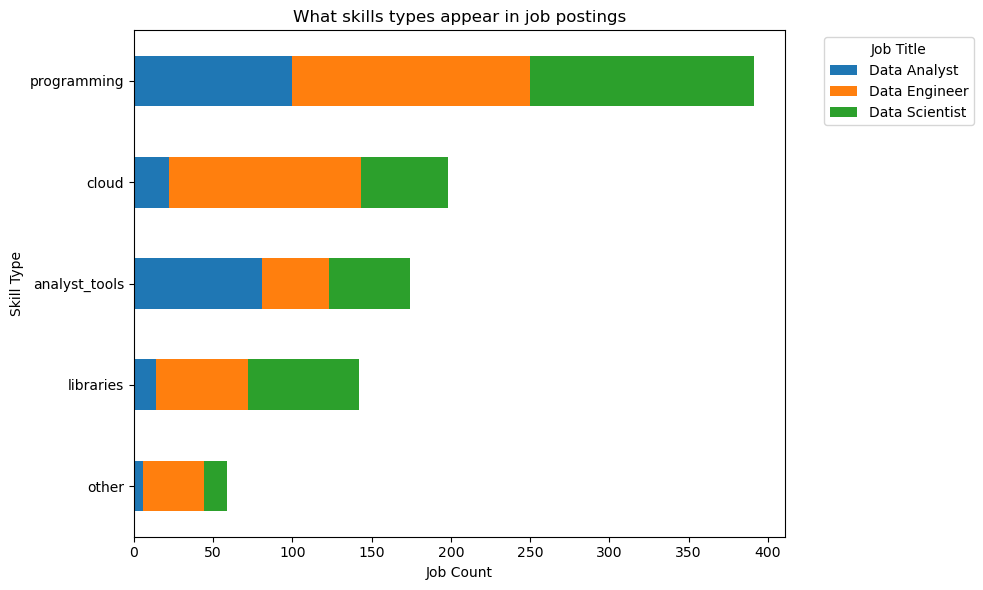

In [52]:
skills_job_pivot_plot_data.plot(
    kind="barh",
    stacked=True,

    figsize=(10, 6),
);


plt.title("What skills types appear in job postings")
plt.xlabel("Job Count")
plt.ylabel("Skill Type")
plt.gca().invert_yaxis()  # Puts the highest total skill type count at the top
plt.legend(title="Job Title", bbox_to_anchor=(1.05, 1), loc='upper left') # Set anchor point and anchor top left of legend box to it
plt.tight_layout()


As an extra analysis, I want to plot the likelihood of a skill type on a stacked bar chart. Meaning what percentage of jobs does each skill type appear in. Also, the percentage must be relative to that specific job title. This is done by the process of data normalisation.
It has 5 steps:
1. Create the base Pivot table without any margin columns
2. Divide each cell by its column sum and multiply the result by 100
3. Sort the data by the highest overall skill type across all jobs (this requires adding a temp column, sorting the data and then dropping the temp column)
4. Add a total row to demonstrate that the normalisation process is complete

In [62]:
# 1. Base Pivot table without any margin columns
skills_job_percentage_pivot = df_UK_group.pivot_table(
    index="skill_type",
    columns="job_title_short",
    values="percentage",
    aggfunc="sum",
    fill_value=0,
)


skills_job_percentage_pivot


job_title_short,Data Analyst,Data Engineer,Data Scientist
skill_type,,,
analyst_tools,28.222997,14.634146,17.770035
async,1.045296,1.742160,3.832753
cloud,7.665505,42.160279,19.163763
databases,3.484321,7.665505,3.135889
libraries,4.878049,20.209059,24.390244
os,0.348432,0.696864,0.696864
other,2.090592,13.240418,5.226481
programming,34.843206,52.264808,49.128920
sync,0.348432,0.348432,1.045296


In [ ]:
# 2. Normalise columns: Divide each cell by its column sum and multiply by 100
skills_normalised = (skills_job_percentage_pivot / skills_job_percentage_pivot.sum(axis=0)) * 100

# 3. Sort by the highest overall skill category total across all jobs
# Add a temporary column called "Overall_Total"
skills_normalised["Overall_Total"] = skills_normalised.sum(axis=1)

# Sort values by this column, and then drop it as it is not required
skills_normalised = skills_normalised.sort_values(by="Overall_Total", ascending=False).drop(columns="Overall_Total")

# 4. Add a total row to demonstrate that the normalisation process is complete and all equal columns now equal 100%
skills_normalised.loc["Total"] = skills_normalised.sum(axis=0)

skills_normalised

job_title_short,Data Analyst,Data Engineer,Data Scientist
skill_type,,,
programming,41.666667,33.936652,39.166667
analyst_tools,33.750000,9.502262,14.166667
cloud,9.166667,27.375566,15.277778
libraries,5.833333,13.122172,19.444444
other,2.500000,8.597285,4.166667
databases,4.166667,4.977376,2.500000
async,1.250000,1.131222,3.055556
webframeworks,0.833333,0.678733,0.833333
sync,0.416667,0.226244,0.833333


I then create a subset of the normalised pivot table using the .head() method. And finally, I plot this subset of data on a stacked horizontal bar chart using the Seaborn library.

In [63]:
# Data subset of top 5 skills
skills_normalised_plot_data = skills_normalised.head()

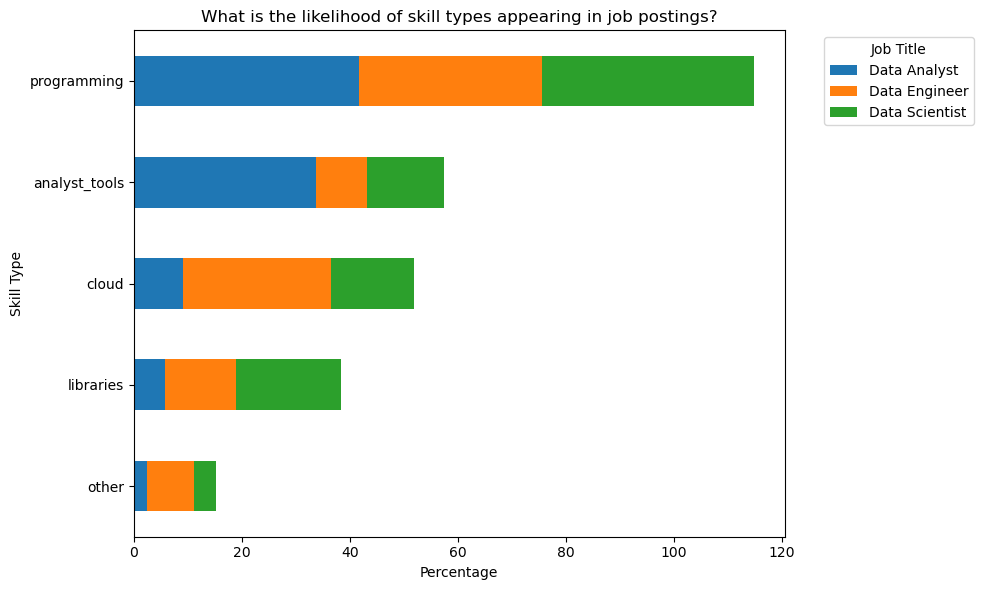

In [64]:
# Plot this subset
skills_normalised_plot_data.plot(
    kind="barh",
    stacked=True,

    figsize=(10, 6),
);


plt.title("What is the likelihood of skill types appearing in job postings?")
plt.xlabel("Percentage")
plt.ylabel("Skill Type")
plt.legend(title="Job Title", bbox_to_anchor=(1.05, 1), loc='upper left') # set anchor point and anchor top left of legend box to it

plt.gca().invert_yaxis()  # Puts the highest total skill at the top
plt.tight_layout()

# Likelihood of Skill Types VS Median Salaries 

In the below plot, I plot the likelihood of skill types vs their median salaries. This is done via 

With adjust text to prevent overlapping points and add pointing arrows if need be (Google Gemini assitance used)

## Format x and y axis ticks with percentage sign and £ sign

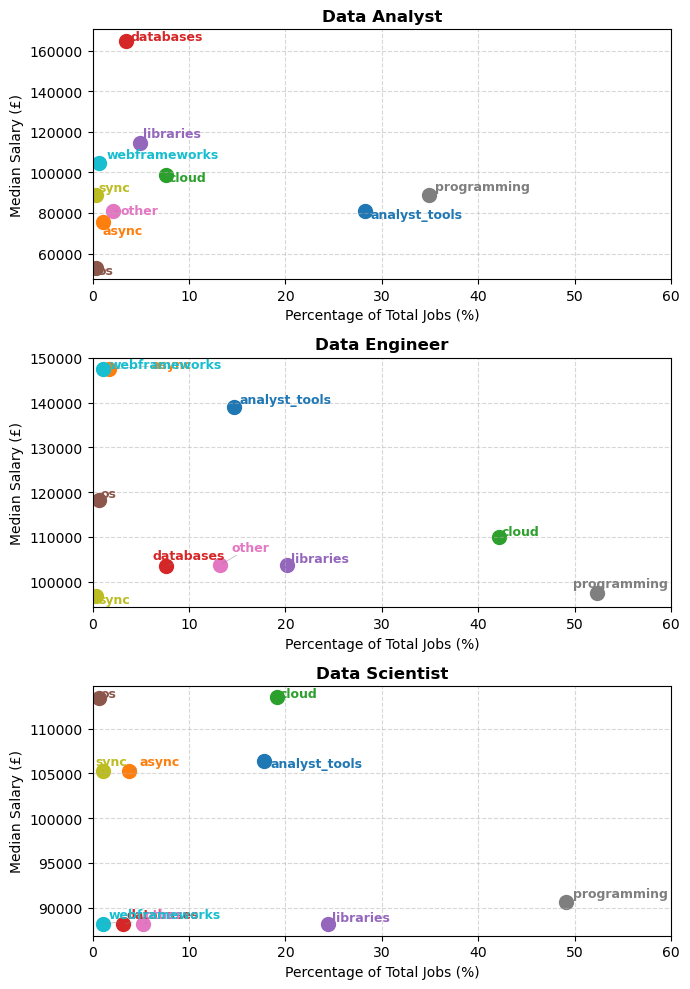

In [ ]:
# 1. MAP COLOURS AND SELECT DATA
# Get a list of all unique skill categories from the DataFrame
unique_skills = df_UK_group["skill_type"].unique()

# Create a distinct colour palette (using 'tab10' which is colour palatte created by the company Tableu) with enough colours for each unique skill (they equal to 10)
colors = sns.color_palette("tab10", len(unique_skills))

# Pair each unique skill with a colour and store it in a lookup dictionary
# zip() 'zips' the skill and colour together into a key value pair via dict()
skill_color_map = dict(zip(unique_skills, colors))

# Get all unique job titles from the data (since there are exactly 3 in the table)
job_titles = df_UK_group["job_title_short"].unique()


# 2. CREATE THE GRAPH GRID
# Initialize a layout with 1 row and 3 columns of subplots (exactly 3 plot areas)
# 'axes' becomes a 1D array containing the 3 blank plotting spaces
fig, axes = plt.subplots(3, 1, figsize=(7, 10))


# 3. GENERATE THE PLOTS
# Simultaneously loop through the 3 blank plot windows and the 3 job titles
for ax, title in zip(axes, job_titles):
    
    # Filter the main DataFrame to get data only relevant to the current job title
    sub_df = df_UK_group[df_UK_group["job_title_short"] == title]
    
    # Create an empty list to keep track of text labels added to this specific subplot
    texts = []
    
    # Loop row-by-row through the filtered data for this specific job title
    for _, row in sub_df.iterrows():
        # Look up the predefined, consistent colour for this specific skill type
        point_color = skill_color_map[row["skill_type"]]
        
        # Draw a single dot on the graph based on percentage (X) and median salary (Y)
        ax.scatter(row["percentage"], row["median_salary"], color=point_color, s=100)
        
        # Place text directly over the dot using coordinates (X, Y) and the skill name string
        txt = ax.text(row["percentage"], row["median_salary"], row["skill_type"], 
                      color=point_color, fontsize=9, weight="bold")
        
        # Save this text object to our list so we can adjust it later
        texts.append(txt)
    
    # Apply standard labels, a title, and a background grid to the current subplot
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel("Percentage of Total Jobs (%)")
    ax.set_ylabel("Median Salary (£)")
    ax.set_xlim(0, 60)
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # 4. RESOLVE LABEL OVERLAPS
    # Automatically nudge overlapping labels apart and draw thin gray connecting lines back to the dots
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5, alpha=0.6))

# Clean up layout spacing to prevent titles and axis labels from clipping or overlapping
plt.tight_layout()
